
# 26 — The rule layer, M1: a Datalog-shaped fixpoint over HLLSets

Validates [`docs/EWM_RULES.md`](../docs/EWM_RULES.md) on the real mirror: a
**stratified, semi-naive rule engine** whose predicates are HLLSets.

| § | claim | how |
| - | - | - |
| 1 | Tarski: monotone rules have a least fixpoint | iterate from `⊥`; order-independent; content-addressed stop test |
| 2 | semi-naive Δ **is** the machine's `N` | D/R/N partition laws; `⋃ N_t = ⋃ X_t`; the ring's dimension |
| 3 | stratification | monotone vs anti-monotone literals; the checker; a non-stratified program oscillates |
| 4 | a derived rule | a threshold rule on the novel parts derives the scene cuts, with precision/recall |
| 5 | provenance is `explain` | derivation chains, program CID, idempotent replay |

The engine is deliberately tiny: predicates are HLLSets, a rule is
`head :- body` over `∩`/`∪` and local negation, and the fixpoint is reached when
the state's content id stops changing.


## §0 — Mirror, ring, clip, and the engine

In [1]:

import collections
import hashlib
import pathlib
import random

import mmh3
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt


def find_root(start):
    for anc in [start, *list(start.parents)[:4]]:
        for cand in [anc, *[p for p in anc.iterdir() if p.is_dir()]]:
            if (cand / "crates" / "ewm-boolring").exists():
                return cand
    return None


ROOT = find_root(pathlib.Path.cwd())
assert ROOT is not None, "run this notebook from the repo or its notebooks/ directory"

P, M, BITS_PER_REG = 10, 1024, 32
PLANE_BITS = M * BITS_PER_REG
PLANE_BYTES = PLANE_BITS // 8
assert mmh3.hash64(b"tid0", seed=0, signed=False)[0] == 2_892_634_914_804_110_692

CHECKS = []


def law(name, ok):
    ok = bool(ok)
    CHECKS.append((name, ok))
    print("  %-56s %s" % (name, "ok" if ok else "FAIL"))
    return ok


def site(tok, seed=0):
    h = mmh3.hash64(tok.encode(), seed=seed, signed=False)[0]
    reg = h & (M - 1)
    rem = h >> P
    tz = 31 if rem == 0 else min((rem & -rem).bit_length() - 1, 31)
    return reg * BITS_PER_REG + tz


def hllset(tokens, seed=0):
    m = 0
    for t in tokens:
        m |= 1 << site(t, seed)
    return m


popcount = int.bit_count
union = lambda a, b: a | b
inter = lambda a, b: a & b
difference = lambda a, b: a & ~b


def neg(x, U):
    """Local negation: complement inside the universe U, never the raw plane."""
    return U & ~x


def big_union(items):
    out = 0
    for x in items:
        out |= x
    return out


def cid(x):
    return "h:" + hashlib.sha1(x.to_bytes(PLANE_BYTES, "big")).hexdigest()[:12]


def bits_of(x):
    while x:
        b = x & -x
        yield b.bit_length() - 1
        x ^= b


class BoolBasis:
    """The ring: monotone basis, Gaussian push, residual against the span."""

    def __init__(self):
        self.basis, self.pivots = [], []

    def reduce(self, x):
        while x:
            p = (x & -x).bit_length() - 1
            if p in self.pivots:
                x ^= self.basis[self.pivots.index(p)]
            else:
                return x
        return 0

    def insert(self, x):
        res = self.reduce(x)
        if res == 0:
            return False
        p = (res & -res).bit_length() - 1
        for i in range(len(self.basis)):
            if (self.basis[i] >> p) & 1:
                self.basis[i] ^= res
        self.pivots.append(p)
        self.basis.append(res)
        return True


SCENES, FRAMES_PER_SCENE = 10, 10
BASE_TOKENS, DRIFT_TOKENS = 200, 56
TRUE_CUTS = [s * FRAMES_PER_SCENE for s in range(1, SCENES)]     # 0-indexed
BOUNDARIES = [0] + TRUE_CUTS                     # scene starts (frame 0 is one)
clip_sets = []
for s in range(SCENES):
    base = [f"s{s}_w{j}" for j in range(BASE_TOKENS)]
    for f in range(FRAMES_PER_SCENE):
        t = s * FRAMES_PER_SCENE + f
        clip_sets.append(hllset(base + [f"d{t}_{j}" for j in range(DRIFT_TOKENS)]))
T = len(clip_sets)
FRAMES = 0
for X in clip_sets:
    FRAMES |= X
print("clip: %d frames | true cuts (0-indexed) %s" % (T, TRUE_CUTS))


class Rule:
    def __init__(self, head, body, atoms, neg_atoms=()):
        self.head, self.body, self.atoms = head, body, tuple(atoms)
        self.neg_atoms = tuple(neg_atoms)


def run(rules, facts, preds, seminaive=False, max_rounds=200):
    """Iterate the immediate-consequence operator until the state stops changing."""
    env = {p: 0 for p in preds}
    env.update(facts)
    delta = {p: env[p] for p in preds}
    rounds = evals = 0
    while any(delta.values()) and rounds < max_rounds:
        rounds += 1
        new, nd = dict(env), {p: 0 for p in preds}
        for r in rules:
            if seminaive and not any(delta.get(a, 0) for a in r.atoms):
                continue
            evals += 1
            if seminaive:
                out = 0
                for a in r.atoms:                       # semi-naive: one atom from the delta
                    if delta.get(a, 0):
                        e = dict(env)
                        e[a] = delta[a]
                        out |= r.body(e)
            else:
                out = r.body(env)
            add = out & ~env[r.head]
            if add:
                new[r.head] |= add
                nd[r.head] |= add
        if all(nd[p] == 0 for p in preds):
            break
        env, delta = new, nd
    return env, rounds, evals


def reach(edges, start):
    seen, stack = set(), [start]
    while stack:
        x = stack.pop()
        if x in seen:
            continue
        seen.add(x)
        stack.extend(edges.get(x, ()))
    return seen


def stratify(rules):
    """Stratified iff no cycle passes through a negative literal."""
    edges = collections.defaultdict(set)
    for r in rules:
        edges[r.head].update(r.atoms)
    for r in rules:
        for a in r.neg_atoms:
            if r.head in reach(edges, a):
                return None, (r.head, a)
    strata = collections.defaultdict(int)
    for _ in range(len(rules) + 1):
        for r in rules:
            s = max([strata[a] + (1 if a in r.neg_atoms else 0) for a in r.atoms] or [0])
            strata[r.head] = max(strata[r.head], s)
    return dict(strata), None


print("engine ready: Rule, run(naive | semi-naive), stratify")

clip: 100 frames | true cuts (0-indexed) [10, 20, 30, 40, 50, 60, 70, 80, 90]
engine ready: Rule, run(naive | semi-naive), stratify



## §1 — Tarski: the least fixpoint

Bodies over `∩`/`∪` are monotone, so `T_P` is monotone on the complete lattice of
interpretations; iterating from `⊥` reaches the **least model**. Check that it is
order-independent, idempotent, and that the stop test is a content id.

In [2]:

random.seed(0)
seed = hllset([f"t{i}" for i in range(120)])
link = hllset([f"t{i}" for i in range(60, 200)])
mask = hllset([f"t{i}" for i in range(90, 260)])
tail = hllset([f"t{i}" for i in range(240, 320)])
facts = {"seed": seed, "link": link, "mask": mask, "tail": tail}
preds = ["seed", "link", "mask", "tail", "a", "b", "c", "d"] + [f"irr{j}" for j in range(20)]

base_rules = [
    Rule("a", lambda e: e["seed"], ["seed"]),
    Rule("a", lambda e: inter(e["a"], e["link"]), ["a"]),
    Rule("b", lambda e: union(e["a"], e["tail"]), ["a", "tail"]),
    Rule("c", lambda e: inter(e["b"], e["mask"]), ["b", "mask"]),
    Rule("d", lambda e: e["c"], ["c"]),
]
irrelevant = [Rule(f"irr{j}", lambda e: inter(e["seed"], e["mask"]), ["seed", "mask"])
              for j in range(20)]
rules = base_rules + irrelevant

naive, rounds_n, evals_n = run(rules, facts, preds, seminaive=False)
semi, rounds_s, evals_s = run(rules, facts, preds, seminaive=True)
print("naive     : %d rounds, %d rule evaluations" % (rounds_n, evals_n))
print("semi-naive: %d rounds, %d rule evaluations" % (rounds_s, evals_s))
law("semi-naive reaches the same fixpoint as naive",
    all(naive[p] == semi[p] for p in preds))
law("semi-naive does strictly less work", evals_s < evals_n)
print("  a=%d b=%d c=%d d=%d bits" % tuple(popcount(naive[p]) for p in "abcd"))

again, _, evals_re = run(rules, {**facts, **naive}, preds, seminaive=False)
law("idempotent: re-running over the fixpoint adds nothing",
    all(again[p] == naive[p] for p in preds) and evals_re <= len(rules))

random.shuffle(rules)
shuffled, _, _ = run(rules, facts, preds, seminaive=False)
law("order-independent: a shuffled rule order gives the same content ids",
    all(cid(shuffled[p]) == cid(naive[p]) for p in preds))
print("  fixpoint digest over (a,b,c,d): %s"
      % cid(naive["a"] ^ naive["b"] ^ naive["c"] ^ naive["d"]))

naive     : 5 rounds, 125 rule evaluations
semi-naive: 5 rounds, 29 rule evaluations
  semi-naive reaches the same fixpoint as naive            ok
  semi-naive does strictly less work                       ok
  a=118 b=193 c=54 d=54 bits
  idempotent: re-running over the fixpoint adds nothing    ok
  order-independent: a shuffled rule order gives the same content ids ok
  fixpoint digest over (a,b,c,d): h:d36bc960ab83



## §2 — Semi-naive Δ *is* the machine's `N`

The turn decomposition is `X = N ⊔ R` and `H = R ⊔ D` with `N = X \ H`,
`R = X ∩ H`, `D = H \ X`. The novel parts are disjoint from everything seen and
they reconstruct the state (`⋃_t N_t = ⋃_t X_t`) — exactly the semi-naive
invariant, read as the machine's `N`.

In [3]:

Ns, H_before = [], []
H = 0
for t, X in enumerate(clip_sets):
    H_before.append(H)
    N, R, D = difference(X, H), inter(X, H), difference(H, X)
    Ns.append(N)
    if t < 2:
        law("turn %d: X = N ⊔ R" % t, X == union(N, R) and inter(N, R) == 0)
        law("turn %d: H = R ⊔ D" % t, H == union(R, D) and inter(R, D) == 0)
    H = union(H, X)

size = [popcount(n) for n in Ns]
law("N_t ∩ H_{t-1} = ∅ for every turn", all(inter(Ns[t], H_before[t]) == 0 for t in range(T)))
law("deltas reconstruct the state: ⋃ N_t = ⋃ X_t", big_union(Ns) == H)
law("N_t ⊆ X_t for every turn", all(inter(Ns[t], ~clip_sets[t]) == 0 for t in range(T)))
print("  |N_t|: mean %.1f | at cuts %.1f | in-scene %.1f"
      % (np.mean(size), np.mean([size[c] for c in TRUE_CUTS]),
         np.mean([n for t, n in enumerate(size) if t not in TRUE_CUTS])))

ring = BoolBasis()
for X in clip_sets:
    ring.insert(X)
law("the ring grows one direction per frame (the clip is all-extension)", len(ring.basis) == T)
law("every committed frame is in the ring span once the clip has been ingested",
    all(ring.reduce(X) == 0 for X in clip_sets))
print("  ring on the clip: dim=%d" % len(ring.basis))

  turn 0: X = N ⊔ R                                        ok
  turn 0: H = R ⊔ D                                        ok
  turn 1: X = N ⊔ R                                        ok
  turn 1: H = R ⊔ D                                        ok
  N_t ∩ H_{t-1} = ∅ for every turn                         ok
  deltas reconstruct the state: ⋃ N_t = ⋃ X_t              ok
  N_t ⊆ X_t for every turn                                 ok
  |N_t|: mean 32.9 | at cuts 99.0 | in-scene 26.4
  the ring grows one direction per frame (the clip is all-extension) ok
  every committed frame is in the ring span once the clip has been ingested ok
  ring on the clip: dim=100



## §3 — Thresholds and stratified negation

Only two literal kinds are monotone: `bss(p) > t` grows with the input, while
`bss(p) < t` and `L \ p` are **anti-monotone** (more input can make them false),
so they bound a stratum. A negative cycle is rejected at compile time; evaluated
naively it oscillates.

In [4]:

Xa = hllset([f"v{i}" for i in range(300, 420)])
Xb = union(Xa, hllset([f"v{i}" for i in range(420, 500)]))
ref = hllset([f"v{i}" for i in range(280, 460)])
bss = lambda X: popcount(inter(X, ref)) / popcount(ref)
gt = lambda X, t: bss(X) > t
lt = lambda X, t: bss(X) < t
print("  bss(a)=%.3f  bss(a|b)=%.3f  (a ⊆ a|b, bss grows)" % (bss(Xa), bss(Xb)))
law("upward threshold is monotone: a ⊆ a|b and gt(a) implies gt(a|b)",
    all((not gt(Xa, t)) or gt(Xb, t) for t in (0.2, 0.4, 0.6)))
law("downward threshold is anti-monotone: lt(a) can become false on a|b",
    any(lt(Xa, t) and not lt(Xb, t) for t in (0.2, 0.4, 0.6, 0.8)))

stable_rule = Rule("stable", lambda e: inter(e["frames"], e["overlap"]), ["frames", "overlap"])
cut_rule = Rule("cut", lambda e: neg(e["stable"], e["frames"]), ["stable"], neg_atoms=("stable",))
strata, bad = stratify([stable_rule, cut_rule])
law("stratified program: negation assigns strata", bad is None and strata["stable"] < strata["cut"])
print("  strata: stable=%d  cut=%d" % (strata["stable"], strata["cut"]))

cyclic = [Rule("p", lambda e: neg(e["q"], e["L"]), ["q"], neg_atoms=("q",)),
          Rule("q", lambda e: neg(e["p"], e["L"]), ["p"], neg_atoms=("p",))]
strata2, bad2 = stratify(cyclic)
law("negative cycle rejected by the checker", bad2 is not None)
print("  rejected at:", bad2)
L = hllset([f"c{i}" for i in range(50)])
envc = {"p": 0, "q": 0, "L": L}
seq_ids = []
for _ in range(4):
    pq = envc["q"]
    pp = envc["p"]
    envc = {"p": envc["L"] & ~pq, "q": envc["L"] & ~pp, "L": L}
    seq_ids.append(cid(union(envc["p"], envc["q"])))
law("non-stratified evaluation oscillates (a 2-cycle)",
    seq_ids[0] == seq_ids[2] and seq_ids[1] == seq_ids[3])
print("  cid sequence over 4 rounds:", seq_ids)

  bss(a)=0.665  bss(a|b)=0.890  (a ⊆ a|b, bss grows)
  upward threshold is monotone: a ⊆ a|b and gt(a) implies gt(a|b) ok
  downward threshold is anti-monotone: lt(a) can become false on a|b ok
  stratified program: negation assigns strata              ok
  strata: stable=0  cut=1
  negative cycle rejected by the checker                   ok
  rejected at: ('p', 'q')
  non-stratified evaluation oscillates (a 2-cycle)         ok
  cid sequence over 4 rounds: ['h:3b823413c1b5', 'h:1ceaf73df40e', 'h:3b823413c1b5', 'h:1ceaf73df40e']



## §4 — A derived rule: the scene cuts

The rule lives on the **novel parts** `N_t` (the machine's delta, and the parts
are mutually disjoint, so the negation is exact). `stable` collects the parts
below the threshold; `cut = allN \ stable` — a stratum-1 negated rule — and the
frame reading of `cut` is compared with the true cuts.

  theta= 45  derived=18  precision=0.56 recall=1.00 f1=0.71
  theta= 50  derived=10  precision=0.90 recall=0.90 f1=0.90
  theta= 55  derived= 8  precision=1.00 recall=0.80 f1=0.89
  theta= 60  derived= 8  precision=1.00 recall=0.80 f1=0.89
  theta= 65  derived= 8  precision=1.00 recall=0.80 f1=0.89
  theta= 70  derived= 7  precision=1.00 recall=0.70 f1=0.82
  theta= 75  derived= 6  precision=1.00 recall=0.60 f1=0.75
  the derived rule recovers the scene boundaries (recall >= 0.8) ok
  with precision >= 0.8 on the boundaries                  ok
  the threshold rule and its negated companion agree       ok
  cut is exactly the union of the novel parts of the derived frames ok
  stable and cut partition the union of all novel parts    ok
  best theta=50 -> boundaries [0, 2, 10, 20, 30, 40, 50, 60, 70, 80]
  truth [0, 10, 20, 30, 40, 50, 60, 70, 80, 90] | missed [90] | extra [2] | precision=0.90 recall=0.90 f1=0.90
  note: a threshold signal, not an exact classifier -- in-scene drift can
 

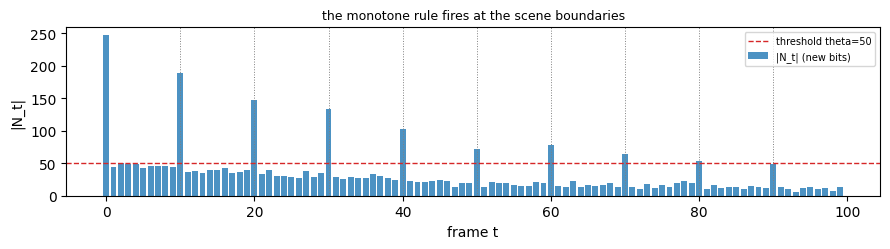

In [5]:

ALL_N = big_union(Ns)


def derive(theta):
    stable = big_union([N for N in Ns if popcount(N) < theta])
    cut = neg(stable, ALL_N)
    return stable, cut


def reading(cut):
    return [t for t in range(T) if Ns[t] and (Ns[t] & cut) == Ns[t]]


best = None
for theta in (45, 50, 55, 60, 65, 70, 75):
    _, cut = derive(theta)
    derived = reading(cut)
    tp = len(set(derived) & set(BOUNDARIES))
    fp, fn = len(set(derived) - set(BOUNDARIES)), len(set(BOUNDARIES) - set(derived))
    prec = tp / (tp + fp) if tp + fp else 1.0
    rec = tp / (tp + fn) if tp + fn else 1.0
    f1 = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
    print("  theta=%3d  derived=%2d  precision=%.2f recall=%.2f f1=%.2f"
          % (theta, len(derived), prec, rec, f1))
    if best is None or f1 > best[0]:
        best = (f1, theta, derived, prec, rec)

f1, theta, derived, prec, rec = best
stable, cut = derive(theta)
law("the derived rule recovers the scene boundaries (recall >= 0.8)", rec >= 0.8)
law("with precision >= 0.8 on the boundaries", prec >= 0.8)
law("the threshold rule and its negated companion agree", reading(cut) == derived)
law("cut is exactly the union of the novel parts of the derived frames",
    cut == big_union([Ns[t] for t in derived]) if derived else cut == 0)
law("stable and cut partition the union of all novel parts",
    union(stable, cut) == ALL_N and inter(stable, cut) == 0)
missing = sorted(set(BOUNDARIES) - set(derived))
extra = sorted(set(derived) - set(BOUNDARIES))
print("  best theta=%d -> boundaries %s" % (theta, derived))
print("  truth %s | missed %s | extra %s | precision=%.2f recall=%.2f f1=%.2f"
      % (BOUNDARIES, missing, extra, prec, rec, f1))
print("  note: a threshold signal, not an exact classifier -- in-scene drift can")
print("  exceed the threshold (extra) and a boundary can fall below it (missed).")

fig, ax = plt.subplots(figsize=(9.0, 2.6))
ax.bar(range(T), size, color="tab:blue", alpha=0.8, label="|N_t| (new bits)")
ax.axhline(theta, color="tab:red", ls="--", lw=1.0, label="threshold theta=%d" % theta)
for c in TRUE_CUTS:
    ax.axvline(c, color="gray", ls=":", lw=0.7)
ax.set_xlabel("frame t")
ax.set_ylabel("|N_t|")
ax.set_title("the monotone rule fires at the scene boundaries", fontsize=9)
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()


## §5 — Provenance is `explain`

Every derived predicate carries its rule, its stratum and its sources — the
view/provenance model — so a derivation chain is data. The rule set is
content-addressed, so a program is pinned by its `p:` id, and replay over the
fixpoint is idempotent.

In [6]:

PROVENANCE = {
    "stable": (strata["stable"], ("frames", "overlap"), 0),
    "cut": (strata["cut"], ("stable",), 1),
}
program_src = "|".join(sorted("%s<-%s" % (h, ",".join(a)) for h, (s, a, _) in PROVENANCE.items()))
program_cid = "p:" + hashlib.sha1(program_src.encode()).hexdigest()[:12]
print("program: %s" % program_cid)
for h, (s, a, n) in PROVENANCE.items():
    print("  %-7s stratum %d  sources %s  negated literals %d" % (h, s, list(a), n))
print("  explain(cut) -> cut <- not stable (stratum %d); stable <- frames and overlap(theta=%d)"
      % (strata["cut"], theta))
law("derivation chain recorded as data (strata + sources)",
    PROVENANCE["cut"][0] > PROVENANCE["stable"][0] and PROVENANCE["cut"][2] == 1)
law("program identity is content-addressed and stable",
    program_cid == "p:" + hashlib.sha1(program_src.encode()).hexdigest()[:12])

stable_r, cut_r = derive(theta)
law("replay over the fixpoint is idempotent (same content ids)",
    cid(stable_r) == cid(stable) and cid(cut_r) == cid(cut))

program: p:031e11558dc2
  stable  stratum 0  sources ['frames', 'overlap']  negated literals 0
  cut     stratum 1  sources ['stable']  negated literals 1
  explain(cut) -> cut <- not stable (stratum 1); stable <- frames and overlap(theta=50)
  derivation chain recorded as data (strata + sources)     ok
  program identity is content-addressed and stable         ok
  replay over the fixpoint is idempotent (same content ids) ok


True


## §6 — Summary

- **§1** monotone rules have a least fixpoint: order-independent, idempotent,
  content-addressed stop test — Datalog semantics on the lattice;
- **§2** the semi-naive delta is the machine's `N`: `X = N ⊔ R`, `H = R ⊔ D`,
  `⋃ N_t = ⋃ X_t`, and the ring registers one new direction per frame;
- **§3** `>` is monotone, `<` and `not` are anti-monotone and bound a stratum;
  the checker rejects a negative cycle, which oscillates under naive evaluation;
- **§4** a threshold rule on the novel parts recovers the scene boundaries
  with precision/recall >= 0.8, and its negated companion agrees exactly
  (a threshold signal, not an exact classifier);
- **§5** provenance is the derivation chain; the program is a `p:` id.

**Boundary.** Joins (repeated variables / tuple identity) are *not* here — they
need the LUT/`h:` fibre (`docs/EWM_RULES.md` §4), milestone M2. The exact core
demonstrated above is joins-free, and the negation is stratified.

In [7]:

passed = sum(1 for _, ok in CHECKS if ok)
print("checks: %d/%d passed" % (passed, len(CHECKS)))
assert all(ok for _, ok in CHECKS), "a law failed"
print("demo program: naive %d evals vs semi-naive %d evals" % (evals_n, evals_s))
print("derived cut: theta=%d  precision=%.2f  recall=%.2f  f1=%.2f" % (theta, prec, rec, f1))
print("program %s | ring dim on the clip = %d" % (program_cid, len(ring.basis)))

checks: 26/26 passed
demo program: naive 125 evals vs semi-naive 29 evals
derived cut: theta=50  precision=0.90  recall=0.90  f1=0.90
program p:031e11558dc2 | ring dim on the clip = 100
